# Dunnhumby: The Complete Journey | 03 SQL Business Questions

Twelve questions a retail manager would actually ask, each answered with one SQL query on the clean tables from notebook 02. The goal is to show SQL that answers business questions, not just SQL that runs.

**Rules carried over from the audit**
- Only merchandise lines: `NOT is_nonmerch AND NOT is_zero_line` (fuel, kiosk, coupons and zero-value lines excluded).
- Only weeks 16 to 101: weeks 1 to 15 are panel ramp-up and week 102 is partial.
- Demographic results describe the 801 profiled households, who spend about 3x more than the rest.

**SQL style:** CTEs, window functions and `CASE`-based conditional aggregation, written to run with little or no change in PostgreSQL, SQL Server or BigQuery.

**Outputs:** 3 charts in `outputs/figures/` (`03_*.png`).

In [1]:
!pip -q install -U duckdb
from google.colab import drive
from pathlib import Path
from scipy.stats import spearmanr
import duckdb, pandas as pd, matplotlib.pyplot as plt
drive.mount('/content/drive')
PROJ = Path('/content/drive/MyDrive/Dunnhumby Project')
DATA, FIG = PROJ/'data/processed', PROJ/'outputs/figures'
con = duckdb.connect()
for f in sorted(DATA.glob('*.parquet')): con.execute(f"CREATE OR REPLACE VIEW {f.stem} AS SELECT * FROM '{f}'")
q = lambda s: con.sql(s).df()
pd.set_option('display.max_columns', 50, 'display.width', 200)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 52.3 MB/s eta 0:00:00
Mounted at /content/drive


## Base view
Every question starts from the same filtered view, so the audit rules are applied once and cannot be forgotten in a single query.

In [2]:
con.execute("""
CREATE OR REPLACE VIEW sales AS
SELECT f.*, p.department, p.commodity, p.brand
FROM fact_sales f
JOIN dim_product p ON p.product_id = f.product_id
WHERE NOT f.is_nonmerch AND NOT f.is_zero_line AND f.week_no BETWEEN 16 AND 101
""");

## Q1. What does the business look like in one line?
Headline KPIs for the stable 86-week period.

In [3]:
q("""
SELECT COUNT(DISTINCT household_key) AS households,
       COUNT(DISTINCT basket_id) AS baskets,
       ROUND(SUM(sales_value)) AS sales,
       ROUND(SUM(sales_value) / COUNT(DISTINCT basket_id), 2) AS avg_basket_value,
       ROUND(1.0 * COUNT(*) / COUNT(DISTINCT basket_id), 1) AS avg_lines_per_basket,
       ROUND(1.0 * COUNT(DISTINCT basket_id) / COUNT(DISTINCT household_key) / COUNT(DISTINCT week_no), 2) AS baskets_per_household_per_week,
       ROUND(SUM(sales_value) / COUNT(DISTINCT household_key) / COUNT(DISTINCT week_no), 2) AS spend_per_household_per_week
FROM sales
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,households,baskets,sales,avg_basket_value,avg_lines_per_basket,baskets_per_household_per_week,spend_per_household_per_week
0,2493,230892,6814347.0,29.51,10.2,1.08,31.78


## Q2. Which departments grew and which shrank?
Compares the first 43 weeks (16 to 58) with the last 43 (59 to 101) on a **fixed panel**: households that shopped in both the first 4 weeks (16 to 19) and the last 4 weeks (98 to 101) of the window.

Why a fixed panel: 907 households joined between weeks 13 and 26, so a simple per-household average makes the first half look smaller and every department appears to grow. Growth also includes price inflation, so the meaningful column is `vs_store_pts`: how much faster or slower a department grew than the store as a whole.

In [4]:
q("""
WITH panel AS (
  SELECT household_key
  FROM sales
  GROUP BY household_key
  HAVING MIN(week_no) <= 19 AND MAX(week_no) >= 98
),
d AS (
  SELECT s.department,
         SUM(CASE WHEN s.week_no <= 58 THEN s.sales_value ELSE 0 END) AS h1_sales,
         SUM(CASE WHEN s.week_no >= 59 THEN s.sales_value ELSE 0 END) AS h2_sales
  FROM sales s
  JOIN panel p ON p.household_key = s.household_key
  GROUP BY s.department
),
t AS (SELECT SUM(h2_sales) / SUM(h1_sales) - 1 AS store_growth FROM d)
SELECT department, ROUND(h1_sales) AS h1_sales, ROUND(h2_sales) AS h2_sales,
       ROUND(100 * (h2_sales / h1_sales - 1), 1) AS growth_pct,
       ROUND(100 * (h2_sales / h1_sales - 1 - store_growth), 1) AS vs_store_pts,
       (SELECT COUNT(*) FROM panel) AS panel_households
FROM d CROSS JOIN t
WHERE h1_sales >= 10000
ORDER BY vs_store_pts DESC
""")

,department,h1_sales,h2_sales,growth_pct,vs_store_pts,panel_households
0,COSMETICS,11922.0,13871.0,16.3,10.6,1700
1,SEAFOOD,10883.0,12541.0,15.2,9.5,1700
2,SALAD BAR,10850.0,12425.0,14.5,8.8,1700
3,NUTRITION,38211.0,43405.0,13.6,7.9,1700
4,DELI,98152.0,108845.0,10.9,5.2,1700
5,PRODUCE,214028.0,233326.0,9.0,3.3,1700
6,MEAT-PCKGD,155464.0,164338.0,5.7,0.0,1700
7,PASTRY,46198.0,48701.0,5.4,-0.3,1700
8,GROCERY,1585103.0,1667841.0,5.2,-0.5,1700
9,DRUG GM,410872.0,429373.0,4.5,-1.2,1700


## Q3. How concentrated is revenue across households?
A cumulative window sum ranks households by spend and tracks their running share of total sales (a Pareto curve).

Top 10% of households: 33.9% of sales
Top 20% of households: 52.6% of sales
Top 50% of households: 84.4% of sales


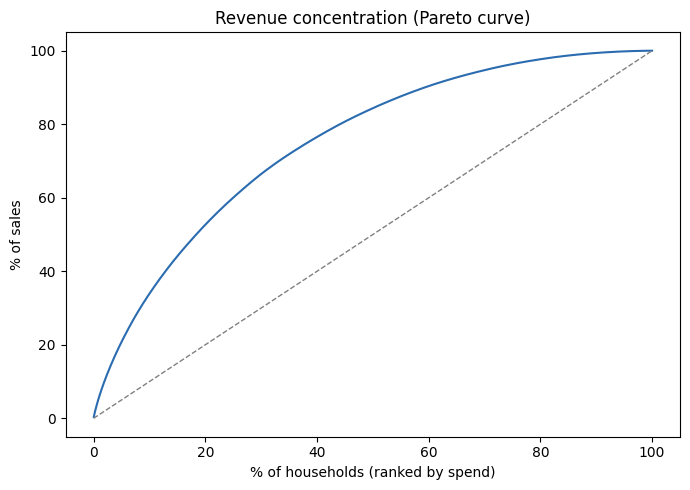

In [5]:
pareto = q("""
WITH hh AS (
  SELECT household_key, SUM(sales_value) AS spend
  FROM sales
  GROUP BY household_key
)
SELECT household_key, spend,
       1.0 * ROW_NUMBER() OVER (ORDER BY spend DESC) / COUNT(*) OVER () AS hh_share,
       SUM(spend) OVER (ORDER BY spend DESC ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) / SUM(spend) OVER () AS sales_share
FROM hh
ORDER BY spend DESC
""")
print(*[f"Top {int(p * 100)}% of households: {pareto.sales_share[pareto.hh_share <= p].max():.1%} of sales" for p in (0.1, 0.2, 0.5)], sep='\n')
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(pareto.hh_share * 100, pareto.sales_share * 100, color='#2b6cb0')
ax.plot([0, 100], [0, 100], color='grey', ls='--', lw=1)
ax.set(xlabel='% of households (ranked by spend)', ylabel='% of sales', title='Revenue concentration (Pareto curve)')
plt.tight_layout(); plt.savefig(FIG/'03_pareto.png', dpi=150); plt.show()

## Q4. Which departments reach the most households, and where is the headroom?
Penetration is the share of households that bought from a department at least once. A department with high spend per buyer but low penetration is a growth opportunity: the households who buy it spend a lot, but most households never do.

In [6]:
q("""
SELECT department,
       COUNT(DISTINCT household_key) AS buyers,
       ROUND(100.0 * COUNT(DISTINCT household_key) / (SELECT COUNT(DISTINCT household_key) FROM sales), 1) AS penetration_pct,
       ROUND(100 * SUM(sales_value) / (SELECT SUM(sales_value) FROM sales), 1) AS sales_share_pct,
       ROUND(SUM(sales_value) / COUNT(DISTINCT household_key), 2) AS spend_per_buyer
FROM sales
GROUP BY department
HAVING COUNT(*) >= 1000
ORDER BY sales_share_pct DESC
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,department,buyers,penetration_pct,sales_share_pct,spend_per_buyer
0,GROCERY,2491,99.9,55.5,1518.22
1,DRUG GM,2477,99.4,14.3,393.75
2,PRODUCE,2431,97.5,7.6,211.77
3,MEAT,2311,92.7,7.4,218.71
4,MEAT-PCKGD,2360,94.7,5.6,160.52
5,DELI,2201,88.3,3.5,109.20
6,PASTRY,2222,89.1,1.7,50.60
7,NUTRITION,1646,66.0,1.3,55.36
8,SEAFOOD-PCKGD,1593,63.9,0.9,36.75
9,FLORAL,1104,44.3,0.5,33.09


## Q5. Does private label share change with household income?
Private label brands are the retailer's own and usually carry higher margins. Income is text such as `'Under 15K'` or `'50-74K'`, so the query extracts the lower bound for correct ordering. This uses the 801 profiled households only.

In [7]:
pl = q("""
WITH hh AS (
  SELECT h.household_key, h.income,
         COALESCE(TRY_CAST(SPLIT_PART(REPLACE(REPLACE(h.income, 'K', ''), '+', ''), '-', 1) AS INTEGER), 0) AS income_floor_k,
         SUM(CASE WHEN s.brand = 'Private' THEN s.sales_value ELSE 0 END) / SUM(s.sales_value) AS private_share
  FROM sales s
  JOIN dim_household h ON h.household_key = s.household_key
  WHERE h.has_demo
  GROUP BY 1, 2, 3
)
SELECT household_key, income, income_floor_k, private_share FROM hh
""")
rho = spearmanr(pl.income_floor_k, pl.private_share)
print(f"Spearman rho (income vs private label share) = {rho.statistic:.3f}, p = {rho.pvalue:.3g}")
pl.groupby(['income_floor_k', 'income']).private_share.agg(households='count', median_private_share_pct=lambda s: round(100 * s.median(), 1)).reset_index(level=0, drop=True)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Spearman rho (income vs private label share) = -0.247, p = 1.46e-12


,households,median_private_share_pct
income,,
Under 15K,61,23.1
15-24K,74,23.6
25-34K,77,23.2
35-49K,172,23.7
50-74K,192,19.6
75-99K,96,18.5
100-124K,34,20.8
125-149K,38,18.6
150-174K,30,16.3


Spearman correlation is used because income is an ordered band, not a continuous number, and private label share is not normally distributed. The test runs at household level, so each household counts once.

## Q6. When do people shop?
Baskets are built first (one row per basket), then grouped by hour. `DAY` has no calendar date, so the day-of-week is a relative index (`day % 7`): the pattern is real, but index 0 is not necessarily Sunday.

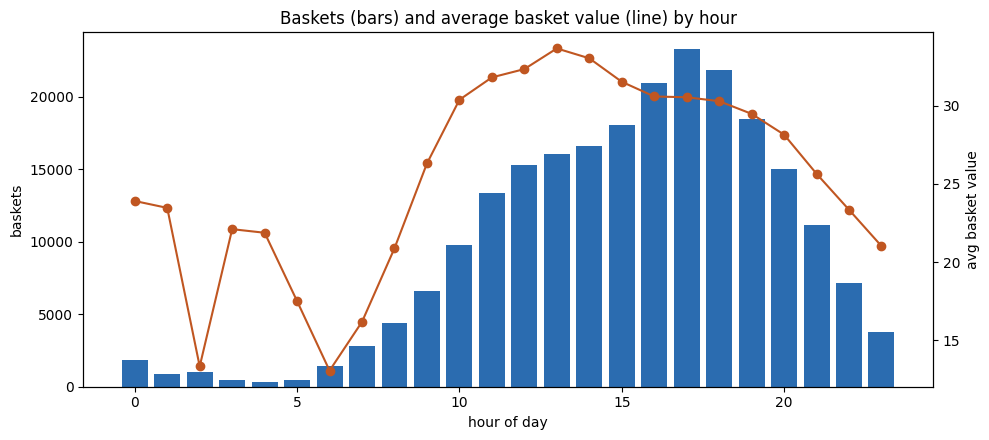

,hour,baskets,baskets_pct,avg_basket_value
0,0,1866,0.8,23.90
1,1,903,0.4,23.46
2,2,1035,0.4,13.33
3,3,438,0.2,22.10
4,4,339,0.1,21.87
5,5,474,0.2,17.50
6,6,1439,0.6,13.06
7,7,2824,1.2,16.18
8,8,4375,1.9,20.88
9,9,6577,2.8,26.30


In [8]:
hourly = q("""
WITH b AS (
  SELECT basket_id, MIN(trans_hour) AS hour, MIN(day) AS day, SUM(sales_value) AS basket_value
  FROM sales
  GROUP BY basket_id
)
SELECT hour, COUNT(*) AS baskets, ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS baskets_pct,
       ROUND(AVG(basket_value), 2) AS avg_basket_value
FROM b
GROUP BY hour
ORDER BY hour
""")
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(hourly.hour, hourly.baskets, color='#2b6cb0')
ax2 = ax.twinx()
ax2.plot(hourly.hour, hourly.avg_basket_value, color='#c05621', marker='o')
ax.set(xlabel='hour of day', ylabel='baskets', title='Baskets (bars) and average basket value (line) by hour')
ax2.set_ylabel('avg basket value')
plt.tight_layout(); plt.savefig(FIG/'03_hourly_baskets.png', dpi=150); plt.show()
hourly

In [9]:
q("""
WITH b AS (
  SELECT basket_id, MIN(day) AS day, SUM(sales_value) AS basket_value
  FROM sales
  GROUP BY basket_id
)
SELECT day % 7 AS day_index, COUNT(*) AS baskets, ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS baskets_pct,
       ROUND(AVG(basket_value), 2) AS avg_basket_value
FROM b
GROUP BY 1
ORDER BY 1
""")

,day_index,baskets,baskets_pct,avg_basket_value
0,0,30689,13.3,28.07
1,1,30705,13.3,27.43
2,2,30853,13.4,27.37
3,3,31743,13.7,29.48
4,4,36989,16.0,31.45
5,5,37509,16.2,32.65
6,6,32404,14.0,29.08


## Q7. How are weekly sales trending?
A 4-week moving average smooths out noise, and `LAG` gives the week-over-week change. Spend per active household separates real demand changes from the number of households shopping that week.

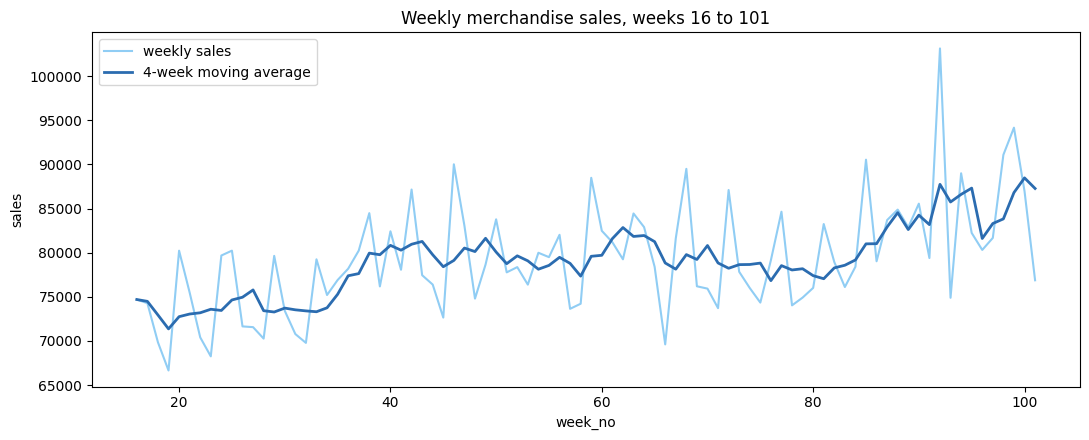

,week_no,sales,sales_ma4,wow_pct,active_hh,spend_per_active_hh
76,92,103149.0,87746.0,29.9,1397,73.84
30,46,90017.0,79124.0,23.9,1307,68.87
4,20,80226.0,72748.0,20.4,1294,62.00
43,59,88486.0,79591.0,19.2,1363,64.92
78,94,88998.0,86607.0,18.8,1329,66.97


In [10]:
weekly = q("""
WITH w AS (
  SELECT week_no, SUM(sales_value) AS sales, COUNT(DISTINCT household_key) AS active_hh
  FROM sales
  GROUP BY week_no
)
SELECT week_no, ROUND(sales) AS sales,
       ROUND(AVG(sales) OVER (ORDER BY week_no ROWS BETWEEN 3 PRECEDING AND CURRENT ROW)) AS sales_ma4,
       ROUND(100 * (sales - LAG(sales) OVER (ORDER BY week_no)) / LAG(sales) OVER (ORDER BY week_no), 1) AS wow_pct,
       active_hh, ROUND(sales / active_hh, 2) AS spend_per_active_hh
FROM w
ORDER BY week_no
""")
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(weekly.week_no, weekly.sales, color='#90cdf4', label='weekly sales')
ax.plot(weekly.week_no, weekly.sales_ma4, color='#2b6cb0', lw=2, label='4-week moving average')
ax.set(xlabel='week_no', ylabel='sales', title='Weekly merchandise sales, weeks 16 to 101')
ax.legend()
plt.tight_layout(); plt.savefig(FIG/'03_weekly_trend.png', dpi=150); plt.show()
weekly.nlargest(5, 'wow_pct')

## Q8. What drives each of the top 5 departments?
`ROW_NUMBER() OVER (PARTITION BY department ...)` ranks commodities inside each department, so the top 3 of every department come out of one query.

In [11]:
q("""
WITH c AS (
  SELECT department, commodity, SUM(sales_value) AS sales
  FROM sales
  GROUP BY department, commodity
),
r AS (
  SELECT department, commodity, sales,
         ROW_NUMBER() OVER (PARTITION BY department ORDER BY sales DESC) AS rnk,
         SUM(sales) OVER (PARTITION BY department) AS dept_sales
  FROM c
)
SELECT department, rnk, commodity, ROUND(sales) AS sales, ROUND(100 * sales / dept_sales, 1) AS share_of_department_pct
FROM r
WHERE rnk <= 3
  AND department IN (SELECT department FROM c GROUP BY department ORDER BY SUM(sales) DESC LIMIT 5)
ORDER BY dept_sales DESC, rnk
""")

,department,rnk,commodity,sales,share_of_department_pct
0,GROCERY,1,SOFT DRINKS,298594.0,7.9
1,GROCERY,2,FLUID MILK PRODUCTS,190805.0,5.0
2,GROCERY,3,CHEESE,175983.0,4.7
3,DRUG GM,1,CIGARETTES,88832.0,9.1
4,DRUG GM,2,CANDY - PACKAGED,71303.0,7.3
5,DRUG GM,3,DIAPERS & DISPOSABLES,54985.0,5.6
6,PRODUCE,1,POTATOES,42683.0,8.3
7,PRODUCE,2,SALAD MIX,41556.0,8.1
8,PRODUCE,3,TOMATOES,38175.0,7.4
9,MEAT,1,BEEF,286147.0,56.6


## Q9. Which departments depend most on discounts?
- `pct_sales_on_promo`: share of sales sold with a retail (loyalty card) discount
- `avg_discount_depth_pct`: discount as a share of the pre-discount price on those sales, where the pre-discount value is `sales_value - retail_disc` (discounts are negative)
- `pct_sales_with_coupon`: share of sales where a manufacturer coupon was used

A department where most sales happen on promotion may be training customers to wait for discounts.

In [12]:
q("""
SELECT department, ROUND(SUM(sales_value)) AS sales,
       ROUND(100 * SUM(CASE WHEN retail_disc < 0 THEN sales_value ELSE 0 END) / SUM(sales_value), 1) AS pct_sales_on_promo,
       ROUND(-100 * SUM(retail_disc) / SUM(CASE WHEN retail_disc < 0 THEN sales_value - retail_disc END), 1) AS avg_discount_depth_pct,
       ROUND(100 * SUM(CASE WHEN coupon_disc < 0 THEN sales_value ELSE 0 END) / SUM(sales_value), 1) AS pct_sales_with_coupon
FROM sales
GROUP BY department
HAVING SUM(sales_value) >= 50000
ORDER BY pct_sales_on_promo DESC
""")

,department,sales,pct_sales_on_promo,avg_discount_depth_pct,pct_sales_with_coupon
0,SEAFOOD-PCKGD,58538.0,67.0,33.2,1.2
1,MEAT-PCKGD,378830.0,62.5,31.2,1.3
2,MEAT,505437.0,55.4,37.0,0.0
3,GROCERY,3781891.0,54.5,26.5,2.0
4,DELI,240341.0,41.6,17.2,0.2
5,NUTRITION,91120.0,38.2,24.7,0.7
6,PASTRY,112443.0,29.3,30.8,0.1
7,DRUG GM,975327.0,26.2,27.1,3.4
8,PRODUCE,514815.0,22.9,34.5,0.3


## Q10. Which valuable households have gone quiet?
Each household's weekly spend is measured over weeks 16 to 93. Households with no purchase in the last 8 weeks (94 to 101) have gone quiet. Crossing that with spend above or below the median shows how much weekly revenue sits with lapsed high-value customers.

In [13]:
q("""
WITH hh AS (
  SELECT household_key, MAX(week_no) AS last_week,
         SUM(CASE WHEN week_no <= 93 THEN sales_value ELSE 0 END) / 78.0 AS weekly_spend_before
  FROM sales
  GROUP BY household_key
),
m AS (SELECT PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY weekly_spend_before) AS median_spend FROM hh)
SELECT CASE WHEN last_week >= 94 THEN 'active in last 8 weeks' ELSE 'gone quiet' END AS status,
       CASE WHEN weekly_spend_before >= median_spend THEN 'above median spend' ELSE 'below median spend' END AS value_tier,
       COUNT(*) AS households,
       ROUND(SUM(weekly_spend_before)) AS weekly_spend_at_stake,
       ROUND(AVG(weekly_spend_before), 2) AS avg_weekly_spend
FROM hh CROSS JOIN m
GROUP BY 1, 2
ORDER BY 1 DESC, 2
""")

,status,value_tier,households,weekly_spend_at_stake,avg_weekly_spend
0,gone quiet,above median spend,41,1532.0,37.37
1,gone quiet,below median spend,247,1482.0,6.00
2,active in last 8 weeks,above median spend,1206,65072.0,53.96
3,active in last 8 weeks,below median spend,999,10529.0,10.54


## Q11. How often do households come back?
`LAG` over each household's shopping days gives the gap between visits. The median gap per household shows typical shopping rhythm, and the 95th percentile of all gaps is a data-driven threshold for calling a household lapsed, which notebook 05 will use.

In [14]:
q("""
WITH v AS (SELECT DISTINCT household_key, day FROM sales),
g AS (
  SELECT household_key, day - LAG(day) OVER (PARTITION BY household_key ORDER BY day) AS gap
  FROM v
),
hh AS (
  SELECT household_key, PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY gap) AS median_gap
  FROM g
  WHERE gap IS NOT NULL
  GROUP BY household_key
)
SELECT CASE WHEN median_gap <= 3 THEN '1: every 1-3 days' WHEN median_gap <= 7 THEN '2: every 4-7 days'
            WHEN median_gap <= 14 THEN '3: every 8-14 days' WHEN median_gap <= 30 THEN '4: every 15-30 days'
            ELSE '5: less than monthly' END AS shopping_rhythm,
       COUNT(*) AS households, ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS households_pct
FROM hh
GROUP BY 1
ORDER BY 1
""")

,shopping_rhythm,households,households_pct
0,1: every 1-3 days,520,21.0
1,2: every 4-7 days,965,38.9
2,3: every 8-14 days,571,23.0
3,4: every 15-30 days,282,11.4
4,5: less than monthly,144,5.8


In [15]:
q("""
WITH v AS (SELECT DISTINCT household_key, day FROM sales),
g AS (SELECT day - LAG(day) OVER (PARTITION BY household_key ORDER BY day) AS gap FROM v)
SELECT PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY gap) AS median_gap_days,
       PERCENTILE_CONT(0.9) WITHIN GROUP (ORDER BY gap) AS p90_gap_days,
       PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY gap) AS p95_gap_days
FROM g
WHERE gap IS NOT NULL
""")

,median_gap_days,p90_gap_days,p95_gap_days
0,4.0,14.0,23.0


## Q12. How loyal are households to one store?
For each household, the store with the most spend is its main store. The share of spend in that store shows whether households are single-store shoppers, which decides whether store-level promotions reach a household's whole shop.

In [16]:
q("""
WITH hs AS (
  SELECT household_key, store_id, SUM(sales_value) AS spend
  FROM sales
  GROUP BY household_key, store_id
),
r AS (
  SELECT household_key, spend,
         ROW_NUMBER() OVER (PARTITION BY household_key ORDER BY spend DESC) AS rnk,
         SUM(spend) OVER (PARTITION BY household_key) AS total_spend,
         COUNT(*) OVER (PARTITION BY household_key) AS n_stores
  FROM hs
)
SELECT CASE WHEN spend / total_spend >= 0.9 THEN '1: 90%+ in main store' WHEN spend / total_spend >= 0.7 THEN '2: 70-90%'
            WHEN spend / total_spend >= 0.5 THEN '3: 50-70%' ELSE '4: under 50%' END AS main_store_share,
       COUNT(*) AS households, ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS households_pct,
       ROUND(AVG(n_stores), 1) AS avg_stores_used, ROUND(AVG(total_spend)) AS avg_total_spend
FROM r
WHERE rnk = 1
GROUP BY 1
ORDER BY 1
""")

,main_store_share,households,households_pct,avg_stores_used,avg_total_spend
0,1: 90%+ in main store,863,34.6,2.8,2809.0
1,2: 70-90%,656,26.3,5.2,2873.0
2,3: 50-70%,578,23.2,5.7,2674.0
3,4: under 50%,396,15.9,8.1,2425.0


## Findings

1. **Scale.** Over the 86 stable weeks, 2,493 households made 230,892 trips and spent $6.81M on merchandise. The typical household shops about once a week (1.08 trips) and spends $31.78 per week, with an average basket of $29.51 across 10 lines.
2. **Department trends (Q2).** On the fixed panel, departments are ranked by growth relative to the store average. Total growth includes price inflation, so only the gap to the store average should be read as a real shift in demand.
3. **Revenue is concentrated.** The top 10% of households bring 33.9% of sales and the top 20% bring 52.6%. Half of all households account for 84.4%.
4. **Grocery dominates, and some departments have headroom.** Grocery is 55.5% of sales and reaches almost every household. Seafood (32% of households), spirits (21%), salad bar (44%), floral (44%) and cosmetics (49%) are bought by less than half of households.
5. **Private label share falls with income.** Among profiled households, households earning under $50K put about 23% of their spend into private label, against 13 to 16% for those above $150K (Spearman rho = -0.25, p < 0.001). The top income bands are small (5 to 38 households each), and profiled households are heavier shoppers than average, so this is a pattern within engaged customers, not the whole base.
6. **Shopping peaks late afternoon, big baskets at midday.** 17:00 is the busiest hour (10.1% of baskets), and 16:00 to 18:59 carries 28.7% of all baskets. The largest baskets come at 13:00 ($33.65 against $30.53 at 17:00), which suggests midday stock-up trips and evening top-up trips. Day indexes 4 and 5 are the busiest days (32% of baskets) with the highest basket values, most likely the weekend, although the data has no calendar dates to confirm it.
7. **Sales trend upwards with clear spikes.** The 4-week average rises from about $73K to $87K per week. The biggest jump is week 92 (+29.9%, $103K), consistent with a holiday peak.
8. **Category structure differs.** Grocery is fragmented: its largest commodity, soft drinks, is only 7.9% of the department. Meat is concentrated, with beef at 56.6%. Cigarettes lead Drug GM at 9.1%.
9. **Meat and grocery lean heavily on promotions.** More than half of sales in packaged seafood (67%), packaged meat (62.5%), meat (55.4%) and grocery (54.5%) happen on a loyalty discount, at an average depth of 26 to 37%. Manufacturer coupons are minor (3.4% of sales at most).
10. **Lapsed customers are few and mostly low value.** 288 households (11.6%) did not shop in the last 8 weeks, but only 41 of them were above-median spenders ($1,532 of weekly spend). Active above-median households hold $65,072 of the $78,615 weekly spend (83%).
11. **Most households shop weekly.** The median gap between visits is 4 days, and 60% of households shop at least weekly. Only 5% of gaps exceed 23 days, so a household unseen for more than about 3 weeks is behaving unusually. Notebook 05 uses 23 days as its lapse threshold and tests 28 days as a sensitivity check.
12. **Store loyalty is weaker than expected.** Only 34.6% of households spend 90% or more in one store, and 39% spend less than 70% there, using 6 to 8 stores on average. Total spend is broadly similar across these groups ($2,400 to $2,900 per household), so multi-store households are not low-value customers. They are valuable customers whose spend is split.

All results are descriptive. They show where to look, not what causes what.

## Recommendations
1. **Protect the top 20% of households.** They carry over half of sales, so a small loss here costs more than any other group. Give them a loyalty tier with personalised offers, and track their visit gaps closely.
2. **Trigger win-back offers after 3 weeks of silence, not 8.** The data shows 23 days without a visit is already unusual (95th percentile). Acting at that point reaches customers before they settle into another store, which matters more because many already shop across several stores.
3. **Test lower promotion depth in meat and grocery.** With over half of sales on discount at 26 to 37% off, customers may be trained to wait for deals. Run a controlled test in a few stores, reducing depth on selected items, and measure the change in volume and margin.
4. **Position private label by income.** Lower-income households already lean on private label, so value messaging should target them. Higher-income households barely use it, which points to room for a premium private label line.
5. **Plan staff and stock around the 16:00 to 19:00 peak, and promotions around midday and the busiest days.** Midday and day-index 4 and 5 baskets are the largest, which makes them the best slots for stock-up offers.
6. **Cross-sell low-penetration departments.** Seafood and salad bar are bought by less than half of households, while meat and produce reach over 90%. Placing and promoting them alongside meat and produce is a cheap way to test whether reach can grow.